# Практическая работа №4: Взаимодействие процессов — Задача «производитель-потребитель»

## Теоретическая справка
Классическая задача синхронизации процессов:
- **Производитель** создаёт элементы и помещает их в буфер ограниченной ёмкости
- **Потребитель** извлекает элементы из буфера для обработки
- При заполненном буфере производитель ждёт; при пустом — потребитель ждёт

В SimPy для буфера используется `simpy.Store` или `simpy.FilterStore`.

In [ ]:
!pip install simpy

In [2]:
import simpy
import random

# Процесс: производитель генерирует задания
def producer(env, store, id):
    item_num = 0
    while True:
        yield env.timeout(random.uniform(1, 3))
        item_num += 1
        item = f'Задание-{id}-{item_num}'
        yield store.put(item)  # Блокируется, если буфер полон
        print(f'{env.now:5.1f} | Производитель {id} создал {item}')

# Процесс: потребитель обрабатывает задания
def consumer(env, store, id):
    while True:
        item = yield store.get()  # Блокируется, если буфер пуст
        print(f'{env.now:5.1f} | Потребитель {id} получил {item}')
        yield env.timeout(random.uniform(2, 4))  # Время обработки
        print(f'{env.now:5.1f} | Потребитель {id} завершил {item}')

# Инициализация среды и буфера (ёмкость = 5)
env = simpy.Environment()
buffer = simpy.Store(env, capacity=5)

# Запуск 2 производителей и 1 потребителя
for i in range(2):
    env.process(producer(env, buffer, i+1))
env.process(consumer(env, buffer, 1))

# Симуляция
env.run(until=25)

  1.0 | Производитель 1 создал Задание-1-1
  1.0 | Потребитель 1 получил Задание-1-1
  2.7 | Производитель 2 создал Задание-2-1
  3.4 | Потребитель 1 завершил Задание-1-1
  3.4 | Потребитель 1 получил Задание-2-1
  3.7 | Производитель 1 создал Задание-1-2
  5.2 | Производитель 2 создал Задание-2-2
  6.3 | Производитель 1 создал Задание-1-3
  6.6 | Потребитель 1 завершил Задание-2-1
  6.6 | Потребитель 1 получил Задание-1-2
  7.0 | Производитель 2 создал Задание-2-3
  8.2 | Производитель 1 создал Задание-1-4
  9.0 | Производитель 2 создал Задание-2-4
  9.3 | Потребитель 1 завершил Задание-1-2
  9.3 | Потребитель 1 получил Задание-2-2
 11.0 | Производитель 1 создал Задание-1-5
 11.8 | Потребитель 1 завершил Задание-2-2
 11.8 | Потребитель 1 получил Задание-1-3
 11.8 | Производитель 2 создал Задание-2-5
 15.5 | Потребитель 1 завершил Задание-1-3
 15.5 | Потребитель 1 получил Задание-2-3
 15.5 | Производитель 2 создал Задание-2-6
 19.0 | Потребитель 1 завершил Задание-2-3
 19.0 | Потребите

### Задание 1

In [6]:
import simpy
import random

# Процесс: производитель генерирует задания
def producer(env, store, id):
    item_num = 0
    while True:
        yield env.timeout(random.uniform(1, 3))
        item_num += 1
        item = f'Задание-{id}-{item_num}'
        yield store.put(item)
        # print(f'{env.now:5.1f} | Производитель {id} создал {item}')

# Процесс: потребитель обрабатывает задания
def consumer(env, store, id, stats):
    while True:
        item = yield store.get()
        start = env.now

        # print(f'{env.now:5.1f} | Потребитель {id} получил {item}')
        work_time = random.uniform(2, 4)
        yield env.timeout(work_time)

        stats[id] += (env.now - start)  # накапливаем время работы
        # print(f'{env.now:5.1f} | Потребитель {id} завершил {item}')


# === ЦИКЛ ПО РАЗНЫМ ЁМКОСТЯМ ===
SIM_TIME = 25

for capacity in [3, 5, 10]:
    print("\n" + "="*40)
    print(f"Запуск с buffer_capacity = {capacity}")
    print("="*40)

    env = simpy.Environment()
    buffer = simpy.Store(env, capacity=capacity)

    # статистика загрузки
    stats = {1: 0, 2: 0}

    # Производители
    for i in range(2):
        env.process(producer(env, buffer, i+1))

    # ДВА потребителя
    for i in range(2):
        env.process(consumer(env, buffer, i+1, stats))

    # Симуляция
    env.run(until=SIM_TIME)

    # === ВЫВОД СТАТИСТИКИ ===
    print("\n--- Загрузка потребителей ---")
    for cid in stats:
        load = (stats[cid] / SIM_TIME) * 100
        print(f"Потребитель {cid}: {load:.1f}% занятости")


Запуск с buffer_capacity = 3

--- Загрузка потребителей ---
Потребитель 1: 86.0% занятости
Потребитель 2: 88.4% занятости

Запуск с buffer_capacity = 5

--- Загрузка потребителей ---
Потребитель 1: 85.1% занятости
Потребитель 2: 86.4% занятости

Запуск с buffer_capacity = 10

--- Загрузка потребителей ---
Потребитель 1: 82.8% занятости
Потребитель 2: 73.8% занятости


### Задания 2 и 3

In [7]:
import simpy
import random

# Процесс: производитель генерирует задания
def producer(env, store, id, stats):
    item_num = 0
    while True:
        yield env.timeout(random.uniform(1, 3))
        item_num += 1

        item = {
            "name": f'Задание-{id}-{item_num}',
            "producer": id,
            "created_at": env.now
        }

        yield store.put(item)

        # обновляем максимум очереди
        stats["max_queue"] = max(stats["max_queue"], len(store.items))

        print(f'{env.now:5.1f} | Производитель {id} создал {item["name"]}')


# Процесс: потребитель обрабатывает задания
def consumer(env, store, id, stats):
    while True:
        idle_start = env.now

        # --- ПРИОРИТЕТ: сначала producer 1 ---
        if any(item["producer"] == 1 for item in store.items):
            item = yield store.get(lambda x: x["producer"] == 1)
        else:
            item = yield store.get()

        # считаем простой
        stats["idle_time"][id] += (env.now - idle_start)

        print(f'{env.now:5.1f} | Потребитель {id} получил {item["name"]}')

        # время в буфере
        wait_time = env.now - item["created_at"]
        stats["total_wait_time"] += wait_time
        stats["processed"] += 1

        work_time = random.uniform(2, 4)
        yield env.timeout(work_time)

        print(f'{env.now:5.1f} | Потребитель {id} завершил {item["name"]}')


# === ИНИЦИАЛИЗАЦИЯ ===
SIM_TIME = 25

env = simpy.Environment()

# --- ИСПОЛЬЗУЕМ FilterStore ---
buffer = simpy.FilterStore(env, capacity=5)

# статистика
stats = {
    "total_wait_time": 0,
    "processed": 0,
    "max_queue": 0,
    "idle_time": {1: 0, 2: 0}
}

# Производители
for i in range(2):
    env.process(producer(env, buffer, i+1, stats))

# ДВА потребителя
for i in range(2):
    env.process(consumer(env, buffer, i+1, stats))

# Симуляция
env.run(until=SIM_TIME)


# === ВЫВОД СТАТИСТИКИ ===
print("\n=== СТАТИСТИКА ===")

# Среднее время в буфере
if stats["processed"] > 0:
    avg_wait = stats["total_wait_time"] / stats["processed"]
else:
    avg_wait = 0

print(f"Среднее время в буфере: {avg_wait:.2f}")

# Максимальная длина очереди
print(f"Максимальная длина очереди: {stats['max_queue']}")

# Процент простоя
for cid in stats["idle_time"]:
    idle_percent = (stats["idle_time"][cid] / SIM_TIME) * 100
    print(f"Потребитель {cid}: простой {idle_percent:.1f}%")

  1.1 | Производитель 1 создал Задание-1-1
  1.1 | Потребитель 1 получил Задание-1-1
  2.8 | Производитель 2 создал Задание-2-1
  2.8 | Потребитель 2 получил Задание-2-1
  3.0 | Производитель 1 создал Задание-1-2
  3.4 | Потребитель 1 завершил Задание-1-1
  3.4 | Потребитель 1 получил Задание-1-2
  5.3 | Производитель 2 создал Задание-2-2
  5.8 | Производитель 1 создал Задание-1-3
  6.3 | Потребитель 2 завершил Задание-2-1
  6.3 | Потребитель 2 получил Задание-1-3
  6.7 | Потребитель 1 завершил Задание-1-2
  6.7 | Потребитель 1 получил Задание-2-2
  7.0 | Производитель 1 создал Задание-1-4
  8.2 | Производитель 2 создал Задание-2-3
  9.3 | Производитель 1 создал Задание-1-5
  9.7 | Потребитель 2 завершил Задание-1-3
  9.7 | Потребитель 2 получил Задание-1-4
  9.9 | Производитель 2 создал Задание-2-4
 10.7 | Потребитель 1 завершил Задание-2-2
 10.7 | Потребитель 1 получил Задание-1-5
 12.1 | Производитель 1 создал Задание-1-6
 12.8 | Производитель 2 создал Задание-2-5
 13.4 | Потребител

### Задание 4

In [8]:
import simpy
import random

# Процесс: производитель генерирует задания
def producer(env, store, id, lost_stats):
    item_num = 0
    while True:
        yield env.timeout(random.uniform(1, 3))
        item_num += 1
        item = f'Задание-{id}-{item_num}'

        # === ЕСЛИ БУФЕР ПОЛОН — ТЕРЯЕМ ЗАДАНИЕ ===
        if len(store.items) < store.capacity:
            yield store.put(item)
        else:
            lost_stats[id] += 1  # считаем потери
            # print(f'{env.now:5.1f} | Потеряно {item}')


# Процесс: потребитель обрабатывает задания
def consumer(env, store, id, stats):
    while True:
        item = yield store.get()
        start = env.now

        work_time = random.uniform(2, 4)
        yield env.timeout(work_time)

        stats[id] += (env.now - start)


# === ЦИКЛ ПО РАЗНЫМ ЁМКОСТЯМ ===
SIM_TIME = 25

for capacity in [3, 5, 10]:
    print("\n" + "="*40)
    print(f"Запуск с buffer_capacity = {capacity}")
    print("="*40)

    env = simpy.Environment()
    buffer = simpy.Store(env, capacity=capacity)

    # статистика загрузки
    stats = {1: 0, 2: 0}

    # статистика потерь
    lost_stats = {1: 0, 2: 0}

    # Производители
    for i in range(2):
        env.process(producer(env, buffer, i+1, lost_stats))

    # ДВА потребителя
    for i in range(2):
        env.process(consumer(env, buffer, i+1, stats))

    # Симуляция
    env.run(until=SIM_TIME)

    # === ВЫВОД СТАТИСТИКИ ===
    print("\n--- Загрузка потребителей ---")
    for cid in stats:
        load = (stats[cid] / SIM_TIME) * 100
        print(f"Потребитель {cid}: {load:.1f}% занятости")

    print("\n--- Потерянные задания ---")
    for pid in lost_stats:
        print(f"Производитель {pid}: потеряно {lost_stats[pid]}")


Запуск с buffer_capacity = 3

--- Загрузка потребителей ---
Потребитель 1: 94.0% занятости
Потребитель 2: 77.8% занятости

--- Потерянные задания ---
Производитель 1: потеряно 3
Производитель 2: потеряно 2

Запуск с buffer_capacity = 5

--- Загрузка потребителей ---
Потребитель 1: 73.7% занятости
Потребитель 2: 81.6% занятости

--- Потерянные задания ---
Производитель 1: потеряно 0
Производитель 2: потеряно 2

Запуск с buffer_capacity = 10

--- Загрузка потребителей ---
Потребитель 1: 92.5% занятости
Потребитель 2: 86.4% занятости

--- Потерянные задания ---
Производитель 1: потеряно 0
Производитель 2: потеряно 0


### Задание 5

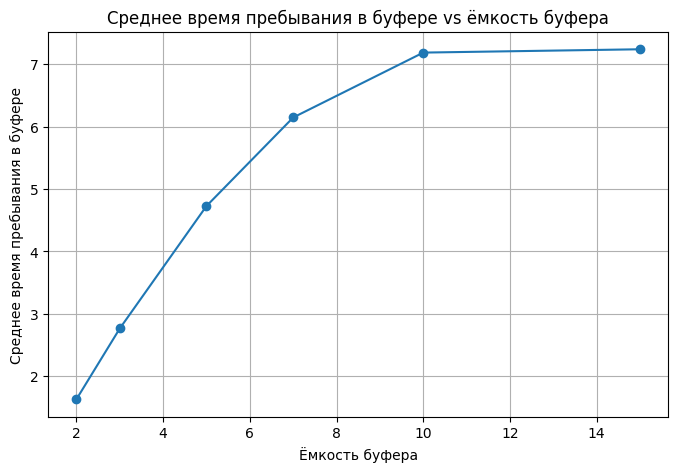

In [9]:
import simpy
import random
import matplotlib.pyplot as plt

# Производитель
def producer(env, store):
    item_num = 0
    while True:
        yield env.timeout(random.uniform(1, 3))
        item_num += 1
        item = {"created_at": env.now}
        if len(store.items) < store.capacity:  # буфер не блокирует
            yield store.put(item)

# Потребитель
def consumer(env, store, stats):
    while True:
        item = yield store.get()
        wait_time = env.now - item["created_at"]
        stats["total_wait"] += wait_time
        stats["count"] += 1
        yield env.timeout(random.uniform(2, 4))

# Симуляция для одной емкости
def simulate(capacity, sim_time=50):
    env = simpy.Environment()
    buffer = simpy.Store(env, capacity=capacity)
    stats = {"total_wait": 0, "count": 0}

    # 2 производителя
    for _ in range(2):
        env.process(producer(env, buffer))

    # 2 потребителя
    for _ in range(2):
        env.process(consumer(env, buffer, stats))

    env.run(until=sim_time)

    if stats["count"] > 0:
        return stats["total_wait"] / stats["count"]
    return 0

# Цикл по разным емкостям
capacities = [2, 3, 5, 7, 10, 15]
avg_waits = []

for c in capacities:
    random.seed(42)  # для воспроизводимости
    avg_waits.append(simulate(c))

# Построение графика
plt.figure(figsize=(8,5))
plt.plot(capacities, avg_waits, marker='o')
plt.xlabel("Ёмкость буфера")
plt.ylabel("Среднее время пребывания в буфере")
plt.title("Среднее время пребывания в буфере vs ёмкость буфера")
plt.grid(True)
plt.show()

## Задание для самостоятельной работы
1. Добавьте второй потребитель и сравните загрузку потребителей при разной ёмкости буфера (3, 5, 10)
2. Реализуйте приоритетную обработку: задания от производителя-1 обрабатываются в первую очередь (используйте `FilterStore`)
3. Соберите статистику:
   - Среднее время нахождения задания в буфере
   - Максимальная длина очереди в буфере
   - Процент времени простоя потребителей
4. Измените логику: при заполнении буфера производитель теряет задание (не ждёт)
5. Постройте график зависимости среднего времени пребывания в буфере от ёмкости

### Ответы

**1. Чем `Store` отличается от `Container` в SimPy?**

Store в SimPy хранит отдельные объекты и позволяет извлекать их по одному или по запросу, а Container хранит количественные значения и оперирует объёмом, а не отдельными элементами.


**2. Как работает механизм блокировки при `put()` в заполненный `Store`?**

Если делать put() в заполненный Store, процесс блокируется до тех пор, пока в нём не освободится место, и только тогда операция завершится.

**3. В каких реальных системах применяется паттерн «производитель-потребитель»?**

Паттерн «производитель-потребитель» применяется в системах с очередями задач, например, в конвейерах, потоковой обработке данных, сетевых серверах и ресторанах с кухней и официантами.

**4. Как избежать потери данных при переполнении буфера в реальных системах?**

Используют механизмы ожидания, динамического расширения буфера или сброса избыточных данных с логированием.

**5. Почему важно ограничивать ёмкость буфера в моделях?**

Это важно для корректного моделирования, чтобы отражать реальные ресурсы системы и предотвращать бесконтрольное накопление задач или объектов.

## Контрольные вопросы
1. Чем `Store` отличается от `Container` в SimPy?
2. Как работает механизм блокировки при `put()` в заполненный `Store`?
3. В каких реальных системах применяется паттерн «производитель-потребитель»?
4. Как избежать потери данных при переполнении буфера в реальных системах?
5. Почему важно ограничивать ёмкость буфера в моделях?